In [2]:
import cv2          # image processing
import numpy as np  # numerical processing
from PIL import Image # image processing
import matplotlib.pyplot as plt # plotting

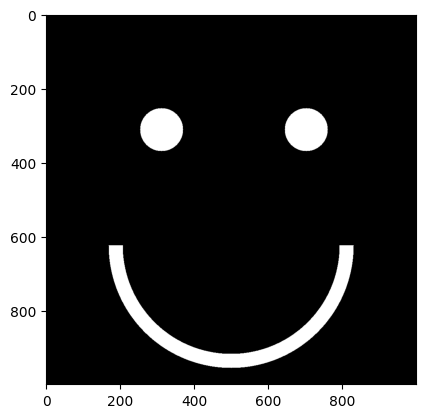

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Create empty 256x256 array
x = 1000

smiley_256 = np.zeros((x, x), dtype=np.uint8)

# Function to draw a circle
def draw_circle(img, center, radius):
    y, x = np.ogrid[:img.shape[0], :img.shape[1]]
    mask = (x - center[0])**2 + (y - center[1])**2 <= radius**2
    img[mask] = 1

# Function to draw a smile (arc of a circle)
def draw_smile(img, center, radius, thickness=3):
    y, x = np.ogrid[:img.shape[0], :img.shape[1]]
    dist = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    # Only keep points in bottom half of the circle (y >= center_y)
    mask = (dist >= radius - thickness) & (dist <= radius + thickness) & (y >= center[1])
    img[mask] = 1

# Draw eyes
draw_circle(smiley_256, center=(int(80/256*x), int(80/256*x)), radius=int(15/256*x))   # Left eye
draw_circle(smiley_256, center=(int(180/256*x), int(80/256*x)), radius=int(15/256*x))  # Right eye

# Draw smile
draw_smile(smiley_256, center=(x//2, int(160/256*x)), radius=int(80/256*x), thickness=int(5/256*x))

# Display
plt.imshow(smiley_256, cmap='gray')
plt.show()

plt.imsave('smiley_256.png', smiley_256, cmap='gray')

In [30]:
smiley_256

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(125, 125), dtype=uint8)

In [24]:
cats = cv2.imread('cats.jpg') # BGR

In [29]:
cats


array([[[64, 48,  2],
        [65, 49,  3],
        [65, 49,  3],
        ...,
        [61, 46,  0],
        [60, 45,  0],
        [60, 45,  0]],

       [[64, 48,  2],
        [65, 49,  3],
        [65, 49,  3],
        ...,
        [62, 47,  1],
        [61, 46,  0],
        [60, 45,  0]],

       [[64, 48,  2],
        [65, 49,  3],
        [65, 49,  3],
        ...,
        [63, 48,  2],
        [62, 47,  1],
        [62, 47,  1]],

       ...,

       [[61, 45,  0],
        [63, 47,  0],
        [64, 48,  1],
        ...,
        [85, 69,  3],
        [84, 68,  2],
        [84, 68,  2]],

       [[59, 43,  0],
        [63, 47,  0],
        [64, 48,  1],
        ...,
        [84, 68,  2],
        [83, 67,  1],
        [82, 66,  0]],

       [[58, 42,  0],
        [62, 46,  0],
        [63, 47,  0],
        ...,
        [83, 67,  1],
        [82, 66,  0],
        [82, 66,  0]]], shape=(1024, 1024, 3), dtype=uint8)

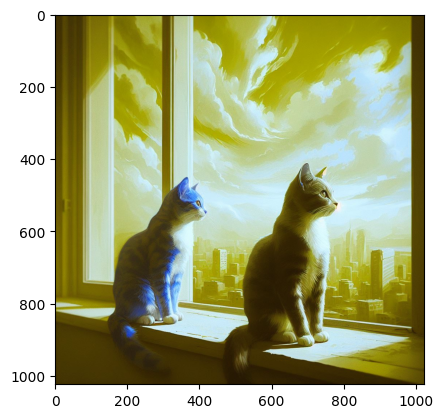

In [31]:
plt.imshow(cats) 
plt.show()

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

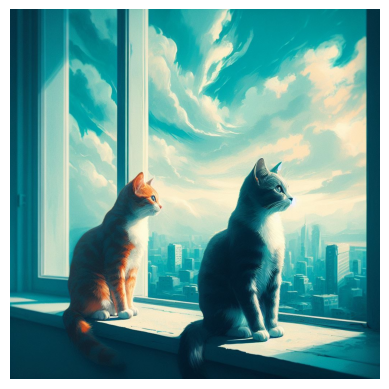

In [27]:
cats_color_converted = cv2.cvtColor(cats, cv2.COLOR_BGR2RGB)
plt.imshow(cats_color_converted)
plt.axis('off')

(-0.5, 1023.5, 1023.5, -0.5)

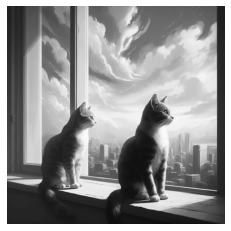

In [6]:
cats_color_grey = cv2.cvtColor(cats, cv2.COLOR_BGR2GRAY)
plt.imshow(cats_color_grey, cmap='gray')
plt.axis('off')

(-0.5, 2047.5, 1023.5, -0.5)

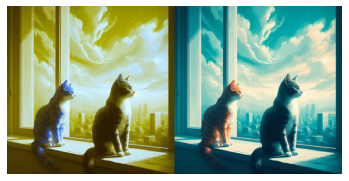

In [7]:
plt.imshow(np.hstack([cats, cats_color_converted]))
plt.axis('off')

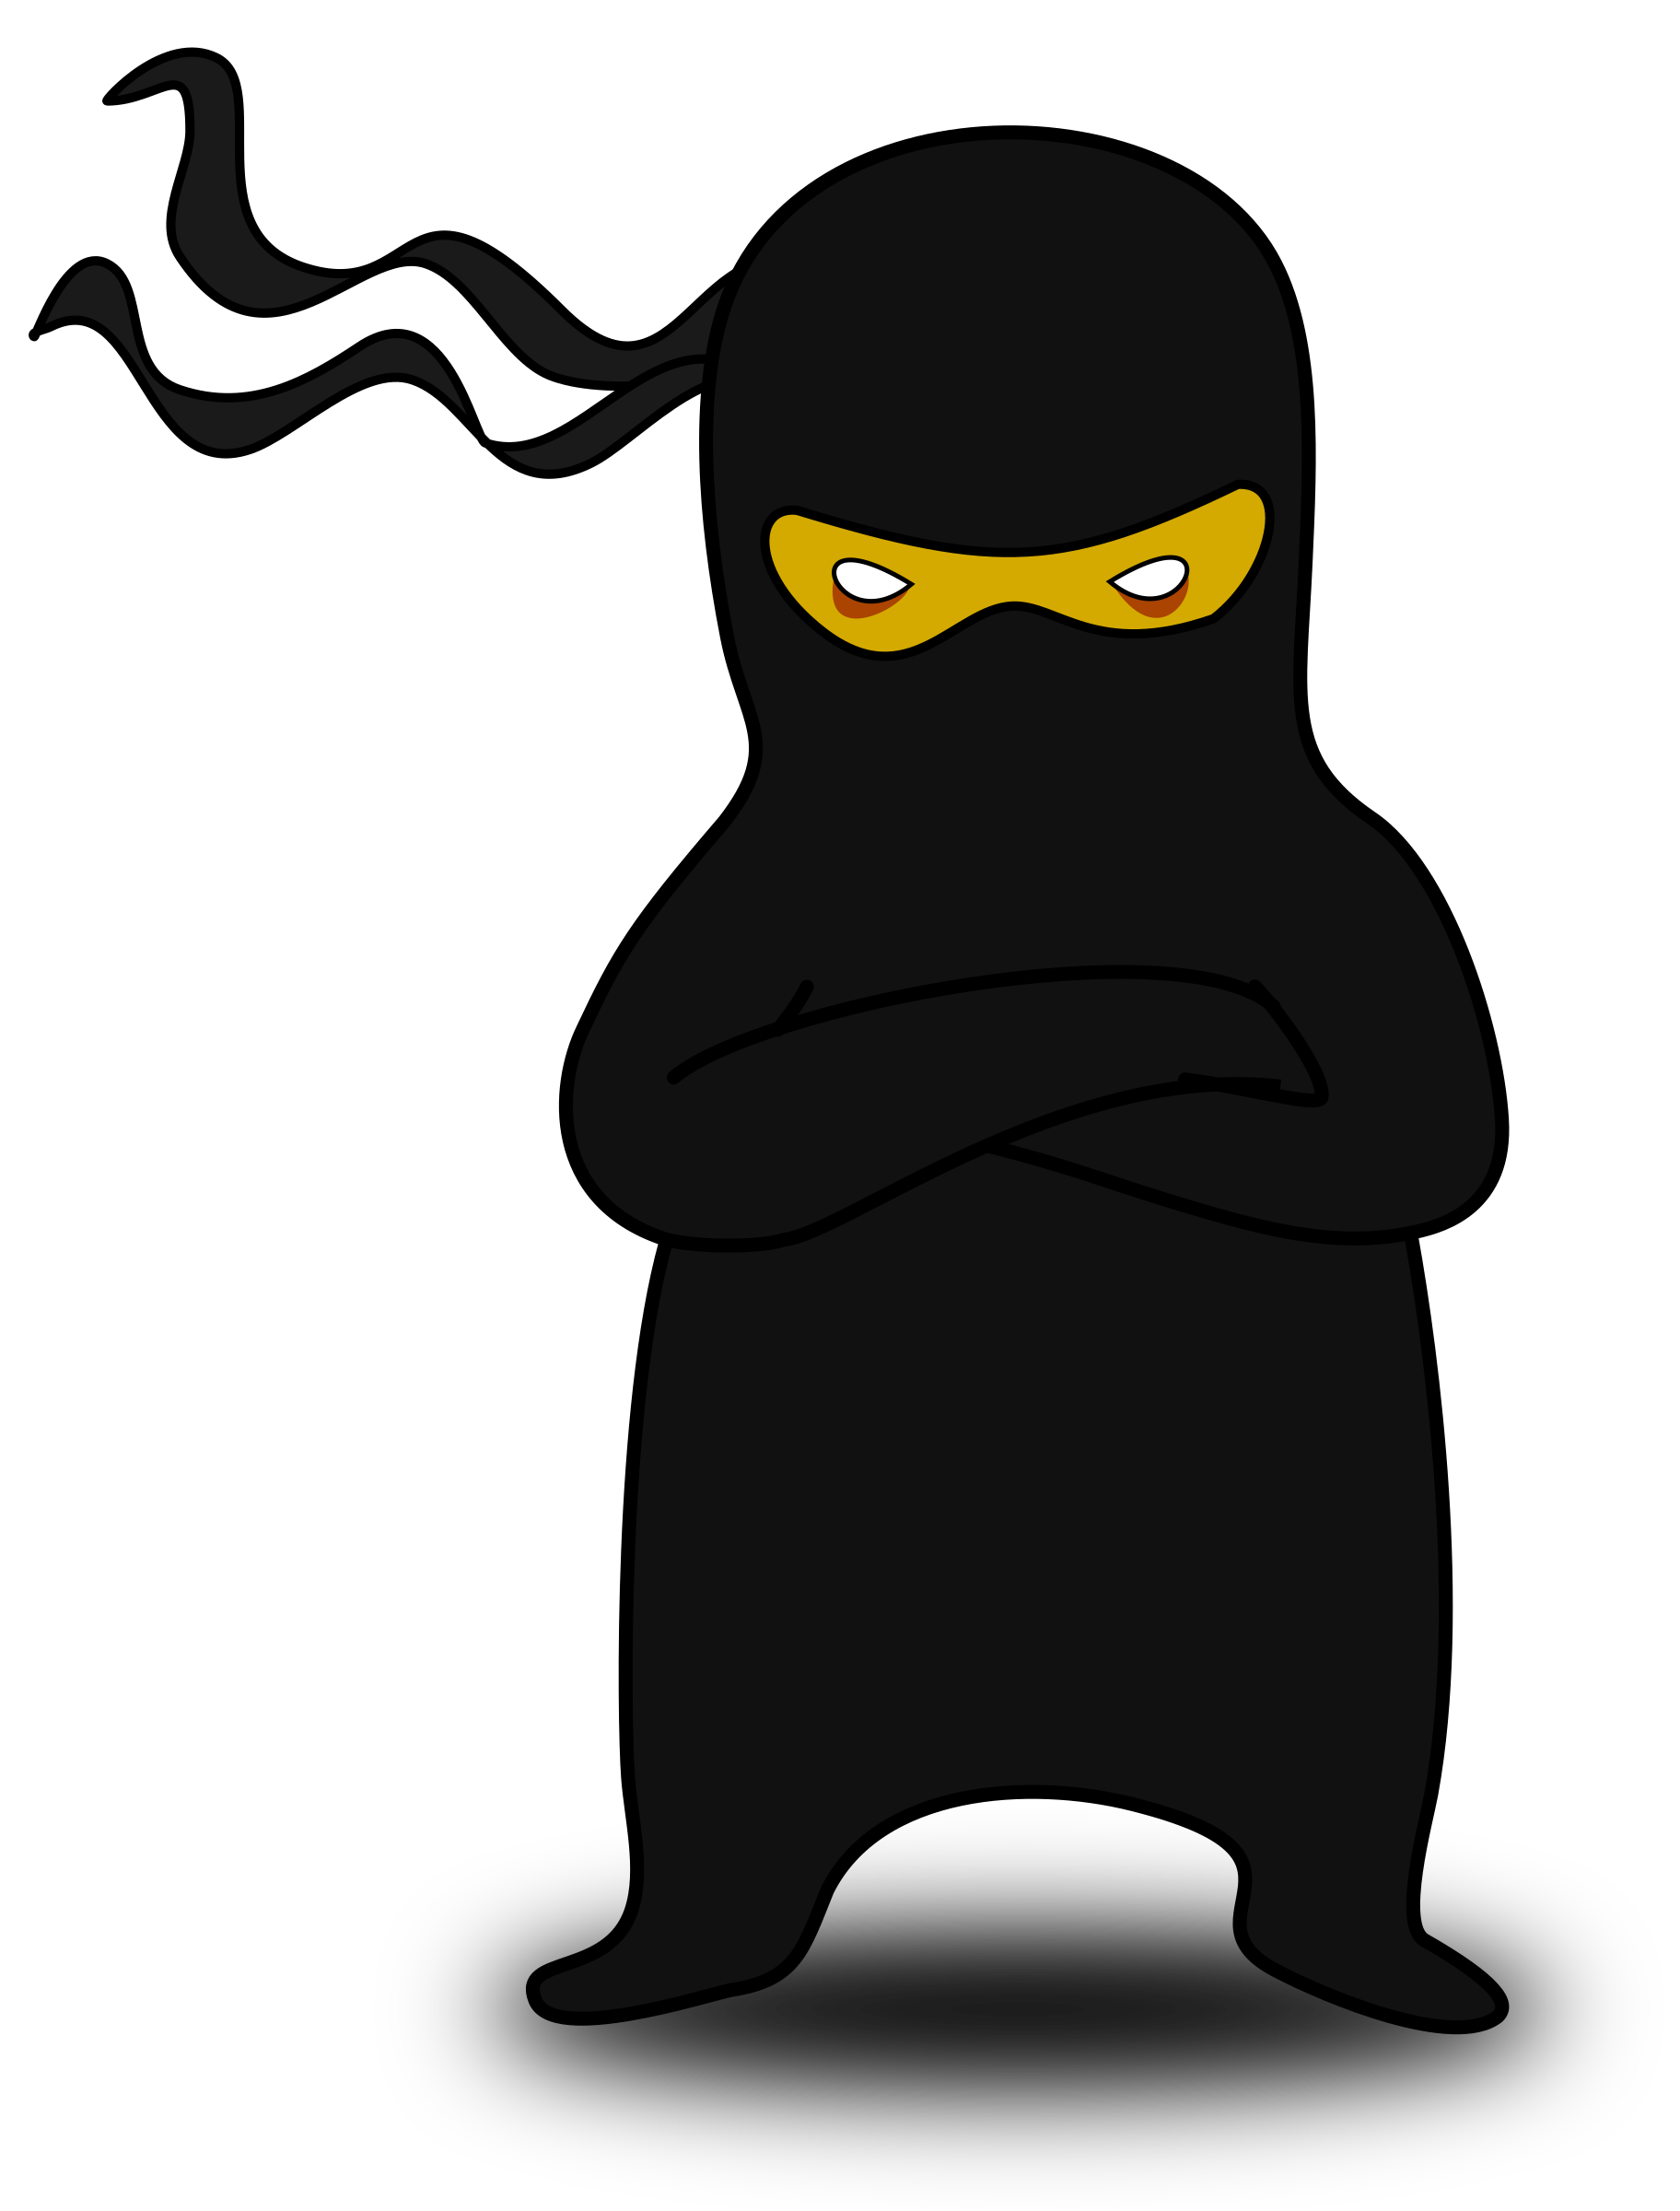

In [8]:
ninja = Image.open('ninja.png')
ninja

In [9]:
np.array(ninja)

array([[[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]],

       [[0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        ...,
        [0, 0, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 0]]], dtype=uint8)

In [10]:
print("image properties")
print(ninja.size)
print(ninja.mode)
print(ninja.format)
print(ninja.info)

image properties
(1824, 2400)
RGBA
PNG
{'dpi': (464.058, 464.058), 'Software': 'www.inkscape.org', 'Title': 'ninja', 'Author': 'hector gomez', 'Creation Time': '2010-11-26T23:21:42', 'Source': 'https://openclipart.org/detail/98407/ninja-by-hector-gomez-98407', 'Copyright': 'CC0 Public Domain Dedication http://creativecommons.org/publicdomain/zero/1.0/'}


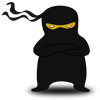

In [11]:
ninja.resize((100,100))

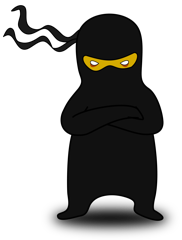

In [12]:
small_ninja = ninja.resize((ninja.width//10, ninja.height//10)) # One Tenths of orignal
small_ninja

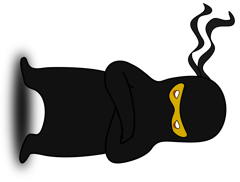

In [13]:
small_ninja.rotate(-90, expand=True)

In [14]:
from PIL import ImageDraw, ImageFont

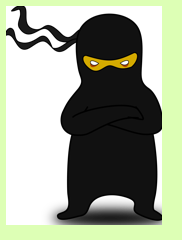

In [15]:
sn = small_ninja.copy()
draw = ImageDraw.Draw(sn)
draw.rectangle((0,0,sn.width, 5), fill='#99ff2054')
draw.rectangle((0,sn.height-15,sn.width, sn.height), fill='#99ff2054')
draw.rectangle((0,0,5, sn.height), fill='#99ff2054')
draw.rectangle((sn.width-20,0,sn.width, sn.height), fill='#99ff2054')
sn

In [17]:
sn.save('small_ninja.png')